# Training dynamics + excluded-loss replay

Step 2 + step 4 of the grokking mechinterp follow-up to [`sobolev_student_character_periodic.ipynb`](../sobolev_student_character_periodic.ipynb).  Nanda's central diagnostic for grokking is *temporal*: train loss drops fast, holdout loss plateaus, Fourier features grow slowly underneath, then "cleanup" locks the model into the circuit.  This notebook checkpoints the periodic-teacher student every ``SNAPSHOT_EVERY`` epochs and replays the probes + the new excluded-loss diagnostic from [`sobolev_distill_character.mechinterp`](../../../sobolev_distill_character/mechinterp.py) at every checkpoint.

Sections: §1 imports + config, §2 train with checkpoints, §3 per-checkpoint diagnostics, §4 per-checkpoint linear probes (R^2 trajectories), §5 per-checkpoint excluded loss at top Fourier modes, §6 plots, §7 takeaway.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import math
import sys
import time
from dataclasses import replace
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


def _polys_root_for_import() -> Path:
    here = Path.cwd().resolve()
    candidates = [
        here / 'graphic_zero_character',
        here.parent / 'graphic_zero_character',
        here.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent.parent / 'graphic_zero_character',
    ]
    for g in candidates:
        if g.is_dir() and (g / '__init__.py').exists():
            return g.parent
    raise FileNotFoundError('Could not locate ml/polys.')


_polys = _polys_root_for_import()
if str(_polys) not in sys.path:
    sys.path.insert(0, str(_polys))

from sobolev_distill_character import (
    CharacterStudentConfig,
    CharacterTrainConfig,
    LinearRampSchedule,
    LossWeights,
    build_character_dataset,
    build_character_teacher_mesh_periodic,
    compute_latents_character,
    dft_trunk_along_axis,
    evaluate_diagnostics_character,
    excluded_loss_at_freqs,
    linear_probes_character,
    make_character_student,
    train_student_character_scheduled_with_checkpoints,
)

print('jax devices:', jax.devices())

jax devices: [CudaDevice(id=0)]


E0515 11:08:45.921110   49328 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0515 11:08:45.930481   49178 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [2]:
MODULUS = 8
MAX_N = 8
MESH_N = 64
LAM = 1.0
EPOCHS_TOTAL = 2000
RAMP_EPOCHS = 200
GRAD_RAMP_END = 0.05
BATCH_SIZE = 256
SNAPSHOT_EVERY = 100
TOPK_MODES = 2  # how many dominant Fourier modes to ablate for excluded loss

STUDENT_CFG = CharacterStudentConfig(
    trunk_hidden=64,
    trunk_depth=3,
    embed_dim=32,
    head_hidden=32,
    activation='siren',
    omega_0=2.5,
    axis_probe=True,
)

WEIGHTS_BASE = LossWeights(
    value=1.0, grad=0.0, hess=0.0, hess_reg=1e-4,
    unit_circle=0.5, axis=1.0, energy_value=0.5,
    energy_pd=0.0, pd_pos_weight=1.0,
)

SCHEDULE = LinearRampSchedule(
    base=WEIGHTS_BASE, field='grad',
    start=0.0, end=GRAD_RAMP_END, ramp_epochs=RAMP_EPOCHS,
)

TRAIN_CFG = CharacterTrainConfig(
    epochs=EPOCHS_TOTAL, batch_size=BATCH_SIZE,
    lr_init=1e-3, lr_min=1e-5, grad_clip=1.0,
    lattice_frac=0.4, chebyshev_frac=0.4,
    weights=WEIGHTS_BASE, log_every=200, seed=0,
)

print(f'snapshot every {SNAPSHOT_EVERY} epochs over {EPOCHS_TOTAL} total = '
      f'{1 + EPOCHS_TOTAL // SNAPSHOT_EVERY} snapshots')

snapshot every 100 epochs over 2000 total = 21 snapshots


## 2. Train periodic-teacher student with checkpoints

Uses ``train_student_character_scheduled_with_checkpoints``; ``snapshots`` is a list of ``(epoch, student_pytree)`` pairs in chronological order.  Initial random init is included as ``epoch=0``.

In [3]:
nodes = np.arange(MAX_N, dtype=np.float64)
teacher = build_character_teacher_mesh_periodic(
    nodes_x=nodes, nodes_y=nodes, p=MODULUS, mesh_n=MESH_N, lam=LAM,
)
ds = build_character_dataset(teacher)

student = make_character_student(jax.random.PRNGKey(0), STUDENT_CFG)
cfg = replace(TRAIN_CFG, weights=SCHEDULE.base)
t0 = time.time()
student, history, snapshots = train_student_character_scheduled_with_checkpoints(
    student, ds, cfg, SCHEDULE, snapshot_every=SNAPSHOT_EVERY,
)
secs = time.time() - t0
print(f'trained in {secs:.1f}s with {len(snapshots)} snapshots')
print(f'snapshot epochs: {[ep for ep, _ in snapshots[:8]]} ... {[ep for ep, _ in snapshots[-3:]]}')

trained in 119.9s with 22 snapshots
snapshot epochs: [0, 0, 100, 200, 300, 400, 500, 600] ... [1800, 1900, 1999]


## 3. Per-checkpoint diagnostics

For every snapshot recompute ``evaluate_diagnostics_character``.  This gives the train-vs-holdout gap, unit-circle residual, and modular recovery accuracy at each training epoch -- the temporal version of the §5 table from the periodic notebook.

In [4]:
rows = []
for epoch_, snap in snapshots:
    d = evaluate_diagnostics_character(snap, ds, teacher)
    rows.append({
        'epoch': int(epoch_),
        'node_value_mse': d.node_value_mse,
        'offlattice_value_mse': d.offlattice_value_mse,
        'unit_circle_residual': d.unit_circle_residual,
        'modular_acc': d.modular_recovery_accuracy,
        'mod_train_minus_holdout': d.modular_acc_train_minus_holdout,
    })

diag_arr = {k: np.asarray([r[k] for r in rows], dtype=np.float64) for k in rows[0]}
print(f'{len(rows)} diagnostic snapshots; final modular_acc = {rows[-1]["modular_acc"]:.3f}')

22 diagnostic snapshots; final modular_acc = 1.000


## 4. Per-checkpoint linear probes

Track how quickly the student's trunk acquires linear decodability for the canonical character targets ``Re zeta^i``, ``Re zeta^j``, and ``Re T[i, j]``.  These curves are the ``R^2`` trajectories Nanda highlights for the Fourier-feature phase.

In [5]:
probe_rows = []
for epoch_, snap in snapshots:
    latents = compute_latents_character(snap, ds, teacher)
    rep = linear_probes_character(latents)
    probe_rows.append({
        'epoch': int(epoch_),
        'r2_re_T':  rep.r2.get('Re T[i,j]', float('nan')),
        'r2_im_T':  rep.r2.get('Im T[i,j]', float('nan')),
        'r2_re_zi': rep.r2.get('Re zeta^i', float('nan')),
        'r2_re_zj': rep.r2.get('Re zeta^j', float('nan')),
    })

probe_arr = {k: np.asarray([r[k] for r in probe_rows], dtype=np.float64) for k in probe_rows[0]}
print(f'final R^2: Re T={probe_rows[-1]["r2_re_T"]:+.3f}  Re zi={probe_rows[-1]["r2_re_zi"]:+.3f}  Re zj={probe_rows[-1]["r2_re_zj"]:+.3f}')

final R^2: Re T=+0.991  Re zi=+0.997  Re zj=+0.993


## 5. Per-checkpoint excluded-loss replay

At each snapshot we (a) identify the top ``TOPK_MODES`` non-DC frequencies in the final-snapshot DFT-along-axis-0 spectrum, (b) re-evaluate the snapshot's value MSE with those frequencies projected out of the trunk activations.  If the student is genuinely operating in the Fourier domain, ablating those modes should send the value MSE up; the rise of that gap over training is the smoking-gun diagnostic for circuit formation.

In [6]:
# Identify dominant modes from the FINAL student's axis-0 DFT.
final_dft = dft_trunk_along_axis(student, ds, teacher, axis=0)
nyq = MODULUS // 2
agg_mag = final_dft.magnitude[:, 1: nyq + 1].sum(axis=0)  # (nyq,)
top_modes = (np.argsort(-agg_mag)[:TOPK_MODES] + 1).tolist()
print(f'top {TOPK_MODES} non-DC modes (final snapshot) = {top_modes}')

excl_rows = []
for epoch_, snap in snapshots:
    out = excluded_loss_at_freqs(snap, ds, teacher, modes=top_modes, component='trunk')
    excl_rows.append({
        'epoch': int(epoch_),
        'baseline_mse': out['baseline_value_mse'],
        'ablated_mse':  out['ablated_value_mse'],
        'baseline_acc': out['baseline_modular_accuracy'],
        'ablated_acc':  out['ablated_modular_accuracy'],
    })

excl_arr = {k: np.asarray([r[k] for r in excl_rows], dtype=np.float64) for k in excl_rows[0]}
rise = excl_arr['ablated_mse'] - excl_arr['baseline_mse']
print(f'excluded-loss gap @ start = {rise[0]:+.4g}, @ end = {rise[-1]:+.4g}')

top 2 non-DC modes (final snapshot) = [1, 2]
excluded-loss gap @ start = +0.01366, @ end = +1.006


## 6. Dynamics plots

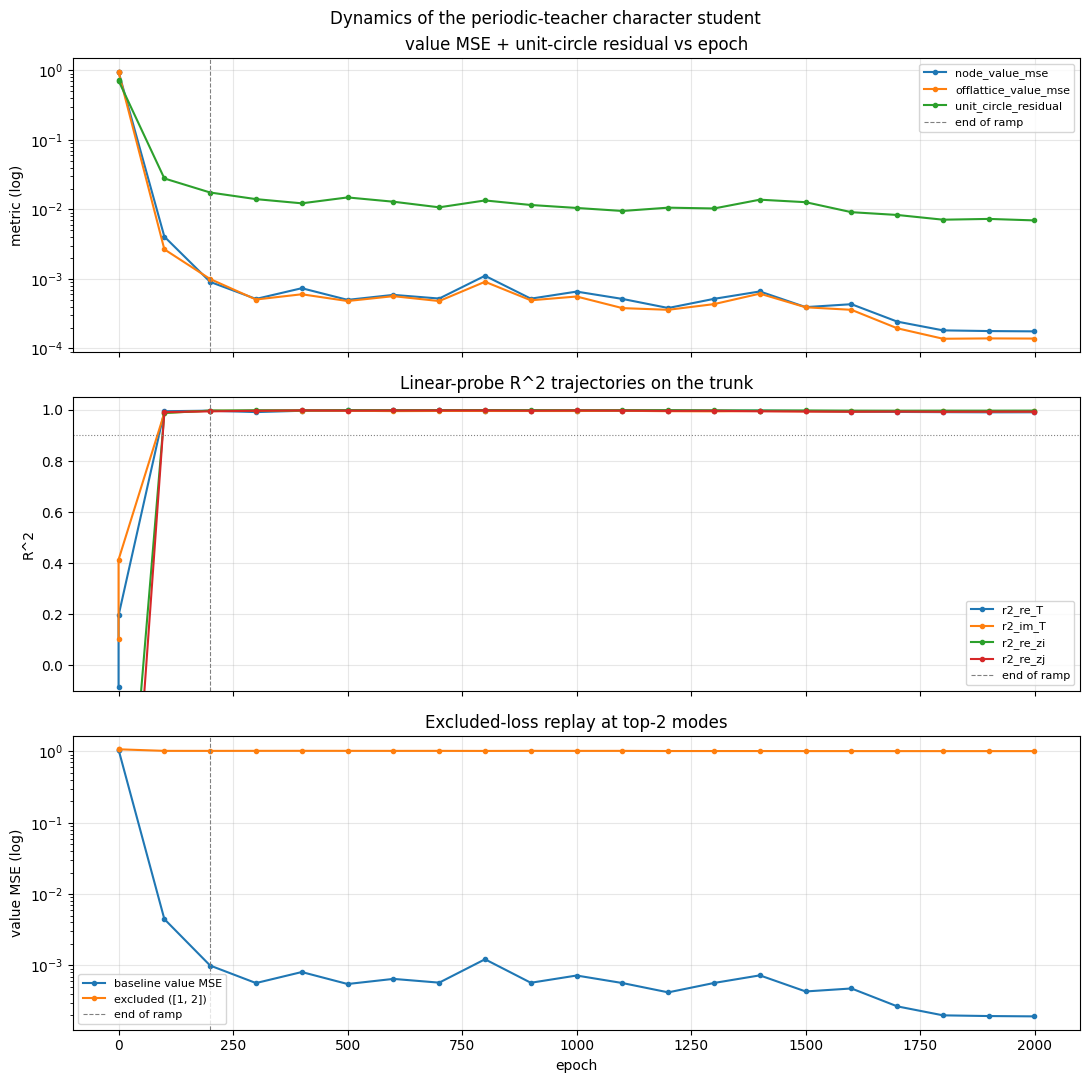

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

ax = axes[0]
epochs = diag_arr['epoch']
ax.plot(epochs, diag_arr['node_value_mse'],       label='node_value_mse',       marker='o', markersize=3)
ax.plot(epochs, diag_arr['offlattice_value_mse'], label='offlattice_value_mse', marker='o', markersize=3)
ax.plot(epochs, diag_arr['unit_circle_residual'], label='unit_circle_residual', marker='o', markersize=3)
ax.set_yscale('log')
ax.set_ylabel('metric (log)')
ax.set_title('value MSE + unit-circle residual vs epoch')
ax.axvline(RAMP_EPOCHS, color='gray', linestyle='--', linewidth=0.8, label='end of ramp')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[1]
for k in ('r2_re_T', 'r2_im_T', 'r2_re_zi', 'r2_re_zj'):
    ax.plot(probe_arr['epoch'], probe_arr[k], marker='o', markersize=3, label=k)
ax.set_ylabel('R^2')
ax.set_ylim(-0.1, 1.05)
ax.axhline(0.9, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(RAMP_EPOCHS, color='gray', linestyle='--', linewidth=0.8, label='end of ramp')
ax.set_title('Linear-probe R^2 trajectories on the trunk')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

ax = axes[2]
epochs = excl_arr['epoch']
ax.plot(epochs, excl_arr['baseline_mse'], marker='o', markersize=3, label='baseline value MSE')
ax.plot(epochs, excl_arr['ablated_mse'],  marker='o', markersize=3, label=f'excluded ({top_modes})')
ax.set_yscale('log')
ax.set_ylabel('value MSE (log)')
ax.set_xlabel('epoch')
ax.set_title(f'Excluded-loss replay at top-{TOPK_MODES} modes')
ax.axvline(RAMP_EPOCHS, color='gray', linestyle='--', linewidth=0.8, label='end of ramp')
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, alpha=0.3)

fig.suptitle('Dynamics of the periodic-teacher character student')
fig.tight_layout()
plt.show()

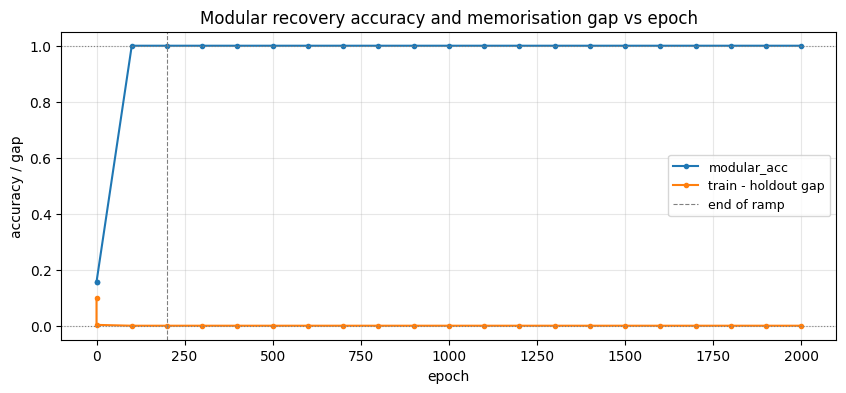

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(diag_arr['epoch'], diag_arr['modular_acc'], marker='o', markersize=3, label='modular_acc')
ax.plot(diag_arr['epoch'], diag_arr['mod_train_minus_holdout'], marker='o', markersize=3, label='train - holdout gap')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(RAMP_EPOCHS, color='gray', linestyle='--', linewidth=0.8, label='end of ramp')
ax.set_xlabel('epoch')
ax.set_ylabel('accuracy / gap')
ax.set_title('Modular recovery accuracy and memorisation gap vs epoch')
ax.legend(fontsize=9, loc='center right')
ax.grid(True, alpha=0.3)
plt.show()

## 7. Takeaway

1. With the periodic teacher in place, the per-epoch checkpoints should make the memorise -> circuit-formation -> cleanup arc visible: value MSE plateauing while ``R^2(\mathrm{Re}\,T[i,j])`` and the per-axis ``R^2(\mathrm{Re}\,\zeta^i)`` climb.
2. The excluded-loss curve quantifies how much of the student's predictive power lives in the named Fourier modes at each epoch.  Under a Nanda-style solution the gap ``ablated - baseline`` widens as those modes become the entire signal.
3. The modular-accuracy / memorisation-gap plot is the analog of the OpenAI grokking trace: with the periodic teacher you expect a brief gap that collapses once the Fourier circuit forms.
4. The remaining mechinterp arc -- helix PCA + causal subspace ablation -- is in [`manifold_and_ablation.ipynb`](manifold_and_ablation.ipynb); the modulus-sweep validation is in [`modulus_sweep.ipynb`](modulus_sweep.ipynb).